# Customer Segmentation Analysis Using RFM and K-Means Clustering

## Project Overview

Customer segmentation is an important data analytics technique used to
understand customers based on their purchasing behaviour. In this project,
we analyse transactional retail data and segment customers into meaningful
groups using **RFM (Recency, Frequency, Monetary) analysis** and the
**K-Means clustering algorithm**.

The objective of this project is to identify different customer segments
and provide actionable marketing strategies for each group.

### Objectives

- Analyse and clean the retail transaction dataset.
- Calculate Recency, Frequency, and Monetary customer-level metrics.
- Standardise the RFM features before clustering.
- Use the Elbow Method to determine an appropriate number of clusters.
- Apply K-Means clustering to segment customers.
- Analyse and visualise the characteristics of each customer segment.
- Recommend suitable marketing strategies for each segment.

### Tools and Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn


### Expected Business Outcome

The analysis aims to help a business identify high-value, loyal, occasional,
and at-risk customers so that marketing campaigns can be better targeted,
customer retention can be improved, and overall revenue can be increased.

In [1]:
print("Customer Segmentation Analysis")
print("RFM Analysis + K-Means Clustering")

Customer Segmentation Analysis
RFM Analysis + K-Means Clustering


## 1. Importing Required Libraries

The first step in the analysis is to import the Python libraries required
for data manipulation, data visualisation, and machine learning.

**Pandas** and **NumPy** are used for data handling and numerical operations.
**Matplotlib** and **Seaborn** are used to create informative visualisations.
From Scikit-learn, **StandardScaler** is used to standardise the RFM features,
while **KMeans** is used to perform customer clustering.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

print("All required libraries imported successfully!")

All required libraries imported successfully!


In [4]:
!wget -O Online_Retail.xlsx "https://archive.ics.uci.edu/static/public/352/online+retail.zip"

--2026-08-20 09:50:53--  https://archive.ics.uci.edu/static/public/352/online+retail.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘Online_Retail.xlsx’

Online_Retail.xlsx      [  <=>               ]  22.62M  73.5MB/s    in 0.3s    

2026-08-20 09:50:54 (73.5 MB/s) - ‘Online_Retail.xlsx’ saved [23715478]



In [5]:
import zipfile
import os

with zipfile.ZipFile("Online_Retail.xlsx", "r") as zip_ref:
    zip_ref.extractall("online_retail_data")

print("Dataset extracted successfully!")
print(os.listdir("online_retail_data"))

Dataset extracted successfully!
['Online Retail.xlsx']


## 3. Loading the Retail Dataset

The cleaned and extracted dataset is now loaded into a Pandas DataFrame.
Pandas provides an efficient way to inspect, clean, transform, and analyse
the transactional data.

Loading the dataset is the foundation of the analysis because it allows us
to understand its structure and prepare the transaction-level information
for customer-level RFM analysis.

In [6]:
file_path = "online_retail_data/Online Retail.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


## 4. Initial Dataset Inspection

The first few records are inspected to understand the structure and content
of the dataset. This helps identify the available variables and gives an
initial understanding of the type of information recorded for each retail
transaction.

In [7]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 5. Dataset Dimensions

The dimensions of the dataset are examined to determine the total number of
transaction records and variables available for analysis.

Understanding the dataset size is important before beginning the data-cleaning
and customer segmentation process.

In [8]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 541909
Number of columns: 8


## 6. Checking Data Types

Before performing data cleaning and RFM analysis, it is important to verify
the data type of each variable.

For example, transaction dates should be stored as datetime values, monetary
variables should be numeric, and customer identifiers should be handled
appropriately. Identifying incorrect data types at this stage helps prevent
errors during subsequent analysis.

In [9]:
df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,float64
Country,object


## 7. Missing Value Analysis

Missing values can affect customer segmentation because the RFM analysis
depends on reliable customer and transaction information.

Therefore, the number of missing values in each column is calculated before
performing any data cleaning. Columns that are essential for customer-level
analysis, particularly `CustomerID`, require special attention.

In [10]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


## 8. Handling Missing Customer IDs

The `CustomerID` column contains missing values. Since customer segmentation
requires grouping transactions by individual customers, transactions without
a valid CustomerID cannot be reliably assigned to a customer segment.

Therefore, rows with missing CustomerID values are removed. The `Description`
column is retained because it is not required for calculating the RFM metrics.

In [11]:
rows_before_customer_cleaning = len(df)

df = df.dropna(subset=["CustomerID"])

rows_after_customer_cleaning = len(df)

print("Rows before cleaning:", rows_before_customer_cleaning)
print("Rows after removing missing CustomerID:", rows_after_customer_cleaning)
print("Rows removed:", rows_before_customer_cleaning - rows_after_customer_cleaning)

Rows before cleaning: 541909
Rows after removing missing CustomerID: 406829
Rows removed: 135080


## 9. Duplicate Record Analysis

Duplicate records can distort customer purchasing behaviour and may lead to
incorrect RFM values, particularly Frequency and Monetary scores.

Therefore, duplicate rows are identified before continuing with the analysis.
If duplicates are found, they will be removed to ensure that each transaction
is represented accurately.

In [12]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 5225


## 10. Removing Duplicate Records

A total of 5,225 duplicate records were identified in the dataset.
These duplicate rows do not provide additional customer behaviour
information and could cause certain purchases to be counted more than once.

Therefore, the duplicate records are removed to improve the accuracy of
the subsequent RFM analysis.

In [13]:
rows_before_duplicates = len(df)

df = df.drop_duplicates()

rows_after_duplicates = len(df)

print("Rows before removing duplicates:", rows_before_duplicates)
print("Rows after removing duplicates:", rows_after_duplicates)
print("Duplicate rows removed:", rows_before_duplicates - rows_after_duplicates)

Rows before removing duplicates: 406829
Rows after removing duplicates: 401604
Duplicate rows removed: 5225


## 11. Identifying Cancelled Transactions

The dataset contains cancelled transactions, which can be identified by
InvoiceNo values beginning with the letter `C`.

Cancelled transactions should not be included when calculating customer
purchasing behaviour because they do not represent completed purchases.
Therefore, these transactions will be identified and excluded from the
RFM analysis.

In [14]:
cancelled_transactions = df["InvoiceNo"].astype(str).str.startswith("C").sum()

print("Number of cancelled transactions:", cancelled_transactions)

Number of cancelled transactions: 8872


## 12. Removing Cancelled Transactions

A total of 8,872 cancelled transactions were identified. Since the objective
of this project is to analyse actual customer purchasing behaviour, cancelled
transactions should not contribute to Recency, Frequency, or Monetary values.

Therefore, these records are removed before calculating the RFM metrics.

In [15]:
rows_before_cancellation = len(df)

df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

rows_after_cancellation = len(df)

print("Rows before removing cancelled transactions:", rows_before_cancellation)
print("Rows after removing cancelled transactions:", rows_after_cancellation)
print("Cancelled transactions removed:", rows_before_cancellation - rows_after_cancellation)

Rows before removing cancelled transactions: 401604
Rows after removing cancelled transactions: 392732
Cancelled transactions removed: 8872


## 13. Checking Invalid Transaction Values

Before calculating the total transaction value, the Quantity and UnitPrice
columns are checked for invalid values.

A valid completed purchase should have a positive quantity and a positive
unit price. Records containing zero or negative values may represent returns,
adjustments, or invalid transactions and can distort the Monetary value.

Therefore, such records will be identified and handled before performing
the RFM analysis.

In [16]:
negative_quantity = (df["Quantity"] <= 0).sum()
invalid_price = (df["UnitPrice"] <= 0).sum()

print("Transactions with Quantity <= 0:", negative_quantity)
print("Transactions with UnitPrice <= 0:", invalid_price)

Transactions with Quantity <= 0: 0
Transactions with UnitPrice <= 0: 40


## 14. Handling Invalid Unit Prices

The analysis identified 40 transactions with a UnitPrice of zero or below.
Since Monetary value is calculated using Quantity multiplied by UnitPrice,
these records could produce misleading transaction values.

As these records do not represent valid positive-price purchases, they are
removed from the dataset before calculating customer-level monetary value.

In [17]:
rows_before_price_cleaning = len(df)

df = df[df["UnitPrice"] > 0]

rows_after_price_cleaning = len(df)

print("Rows before removing invalid prices:", rows_before_price_cleaning)
print("Rows after removing invalid prices:", rows_after_price_cleaning)
print("Invalid price records removed:", rows_before_price_cleaning - rows_after_price_cleaning)

Rows before removing invalid prices: 392732
Rows after removing invalid prices: 392692
Invalid price records removed: 40


## 15. Calculating Total Transaction Value

To measure the monetary contribution of each transaction, a new variable
called `TotalAmount` is created.

The transaction value is calculated by multiplying the quantity purchased
by the unit price:

**TotalAmount = Quantity × UnitPrice**

This variable will later be aggregated at the customer level to calculate
the Monetary component of the RFM analysis.

In [18]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

df[["Quantity", "UnitPrice", "TotalAmount"]].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


## 16. Determining the Analysis Reference Date

Recency measures how recently a customer made a purchase. To calculate
Recency, a reference date is required.

The latest transaction date in the dataset is used as the reference point.
For each customer, the number of days between this reference date and their
most recent purchase will represent their Recency value.

A lower Recency value indicates a more recently active customer.

In [19]:
latest_date = df["InvoiceDate"].max()

print("Latest transaction date:", latest_date)

Latest transaction date: 2011-12-09 12:50:00


## 17. Calculating Customer Recency

Recency represents the number of days since a customer made their most
recent purchase.

For each customer, we identify their latest transaction date and calculate
the number of days between that date and the reference date. Customers with
a smaller Recency value have purchased more recently and are therefore
considered more active.

In [20]:
recency = df.groupby("CustomerID")["InvoiceDate"].max().reset_index()

recency.columns = ["CustomerID", "LastPurchaseDate"]

recency["Recency"] = (
    latest_date - recency["LastPurchaseDate"]
).dt.days

recency.head()

,CustomerID,LastPurchaseDate,Recency
0,12346.0,2011-01-18 10:01:00,325
1,12347.0,2011-12-07 15:52:00,1
2,12348.0,2011-09-25 13:13:00,74
3,12349.0,2011-11-21 09:51:00,18
4,12350.0,2011-02-02 16:01:00,309


## 18. Calculating Customer Purchase Frequency

Frequency measures how often a customer makes purchases.

In this analysis, Frequency is calculated as the number of unique invoices
associated with each customer. Using unique InvoiceNo values prevents
multiple products purchased within the same invoice from being incorrectly
counted as separate purchasing occasions.

A higher Frequency generally indicates stronger customer engagement.

In [21]:
frequency = df.groupby("CustomerID")["InvoiceNo"].nunique().reset_index()

frequency.columns = ["CustomerID", "Frequency"]

frequency.head()

,CustomerID,Frequency
0,12346.0,1
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1


## 19. Calculating Customer Monetary Value

Monetary value represents the total amount of money spent by each customer.

It is calculated by summing the `TotalAmount` of all valid transactions
associated with each CustomerID.

A higher Monetary value indicates that the customer contributes more revenue
to the business.

In [23]:
monetary = df.groupby("CustomerID")["TotalAmount"].sum().reset_index()

monetary.columns = ["CustomerID", "Monetary"]

monetary.head()

,CustomerID,Monetary
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


## 20. Combining RFM Metrics

The Recency, Frequency, and Monetary metrics are now combined into a single
customer-level dataset.

Each row represents one unique customer, while the three RFM variables
summarise that customer's purchasing behaviour. This combined RFM dataset
will be used as the input for the K-Means clustering algorithm.

In [24]:
rfm = recency.merge(frequency, on="CustomerID")
rfm = rfm.merge(monetary, on="CustomerID")

rfm.head()

,CustomerID,LastPurchaseDate,Recency,Frequency,Monetary
0,12346.0,2011-01-18 10:01:00,325,1,77183.60
1,12347.0,2011-12-07 15:52:00,1,7,4310.00
2,12348.0,2011-09-25 13:13:00,74,4,1797.24
3,12349.0,2011-11-21 09:51:00,18,1,1757.55
4,12350.0,2011-02-02 16:01:00,309,1,334.40


## 21. Descriptive Statistics of RFM Features

Descriptive statistics are calculated to understand the overall purchasing
behaviour of the customer base.

The analysis focuses on Recency, Frequency, and Monetary values. These
statistics help identify the typical customer behaviour as well as the
variation between low- and high-value customers.

In [25]:
rfm[["Recency", "Frequency", "Monetary"]].describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,91.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,0.000000,1.000000,3.750000
25%,17.000000,1.000000,306.482500
50%,50.000000,2.000000,668.570000
75%,141.000000,5.000000,1660.597500
max,373.000000,209.000000,280206.020000


## 22. RFM Statistical Summary

The descriptive statistics show substantial variation in customer behaviour.
The average customer made approximately 4.27 purchases and spent around
2,048.69 monetary units.

The median Monetary value is considerably lower than the mean, indicating
that a relatively small number of high-spending customers contribute
significantly to the overall average. Similarly, the wide range of Recency
and Frequency values indicates that customers have very different levels of
engagement with the business.

These variations make clustering particularly useful for identifying
distinct customer groups.

In [26]:
rfm_summary = pd.DataFrame({
    "Mean": rfm[["Recency", "Frequency", "Monetary"]].mean(),
    "Median": rfm[["Recency", "Frequency", "Monetary"]].median(),
    "Standard Deviation": rfm[["Recency", "Frequency", "Monetary"]].std()
})

rfm_summary.round(2)

,Mean,Median,Standard Deviation
Recency,91.54,50.00,100.01
Frequency,4.27,2.00,7.70
Monetary,2048.69,668.57,8985.23


## 23. Distribution of RFM Features

The distributions of Recency, Frequency, and Monetary values are visualised
to better understand customer behaviour.

The Recency distribution shows how recently customers have interacted with
the business. Frequency highlights differences in purchase activity, while
Monetary shows the variation in customer spending.

These visualisations also help identify skewness and unusually high values
that may influence distance-based clustering algorithms.

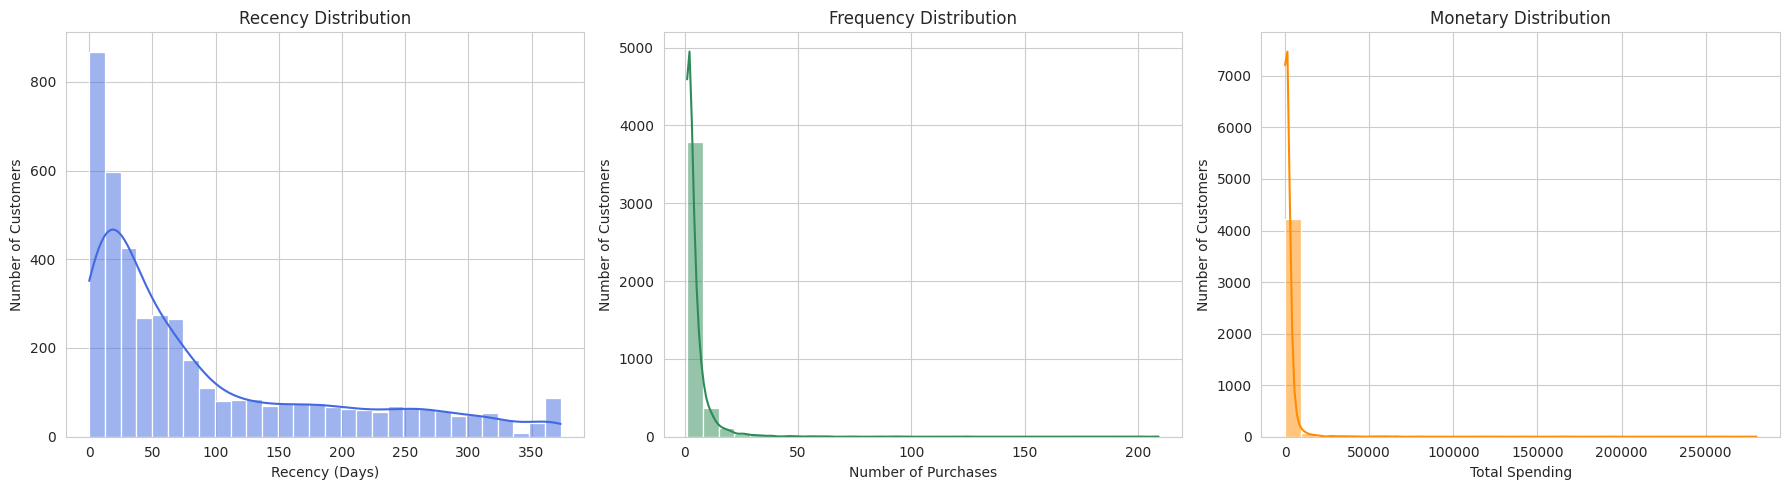

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm["Recency"], bins=30, kde=True, ax=axes[0], color="royalblue")
axes[0].set_title("Recency Distribution")
axes[0].set_xlabel("Recency (Days)")
axes[0].set_ylabel("Number of Customers")

sns.histplot(rfm["Frequency"], bins=30, kde=True, ax=axes[1], color="seagreen")
axes[1].set_title("Frequency Distribution")
axes[1].set_xlabel("Number of Purchases")
axes[1].set_ylabel("Number of Customers")

sns.histplot(rfm["Monetary"], bins=30, kde=True, ax=axes[2], color="darkorange")
axes[2].set_title("Monetary Distribution")
axes[2].set_xlabel("Total Spending")
axes[2].set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Observation

The RFM distributions show noticeable variation in customer purchasing behaviour.
Recency indicates that customers have different levels of recent engagement,
while Frequency shows that most customers make relatively few purchases with
a smaller group purchasing much more frequently.

The Monetary distribution is highly right-skewed, indicating that most
customers spend relatively small amounts while a small number of customers
contribute significantly higher spending. This variation suggests that
customer segmentation can help identify different purchasing behaviour groups.

In [28]:
from sklearn.preprocessing import StandardScaler

rfm_features = rfm[["Recency", "Frequency", "Monetary"]]

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

print("RFM features standardized successfully!")
print("Shape of standardized data:", rfm_scaled.shape)

RFM features standardized successfully!
Shape of standardized data: (4338, 3)


## 24. Determining the Optimal Number of Clusters

The Elbow Method is used to determine a suitable number of customer
segments for K-Means clustering.

K-Means is tested with different values of K. The Within-Cluster Sum of
Squares (inertia) is recorded for each value. As K increases, inertia
decreases. The point where the reduction starts to slow down is known as
the "elbow" and provides an indication of a suitable cluster count.

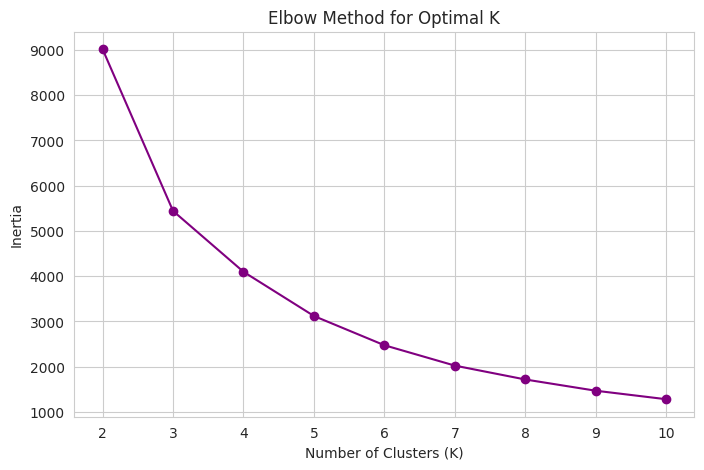

In [29]:
from sklearn.cluster import KMeans

inertia = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker="o", color="purple")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.grid(True)
plt.show()

## 25. Applying K-Means Clustering

Based on the Elbow Method, 4 clusters are selected for customer
segmentation.

K-Means clustering is applied to the standardized Recency, Frequency,
and Monetary features. Standardization ensures that each RFM variable
contributes fairly to the distance calculations.

Each customer is assigned to one of four behavioural segments.

In [30]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print("K-Means clustering completed successfully!")
print("\nCustomers in each cluster:")
print(rfm["Cluster"].value_counts().sort_index())

K-Means clustering completed successfully!

Customers in each cluster:
Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64


## 26. Customer Cluster Profiling

After assigning customers to clusters, each segment is profiled using the
average Recency, Frequency, and Monetary values.

This helps us understand the behavioural characteristics of each customer
segment and provides a basis for developing targeted marketing strategies.

In [31]:
cluster_profile = rfm.groupby("Cluster")[[
    "Recency",
    "Frequency",
    "Monetary"
]].mean().round(2)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,42.70,3.68,1353.63
1,247.08,1.55,478.85
2,6.38,82.54,127187.96
3,14.50,22.33,12690.50


## 27. Number of Customers in Each Cluster

The number of customers in each cluster is visualised using a bar chart.
This helps compare the size of each customer segment.

The results show that Cluster 0 contains the largest customer group,
while Cluster 2 is a very small but highly valuable segment. This indicates
that customer value is not evenly distributed across the customer base.

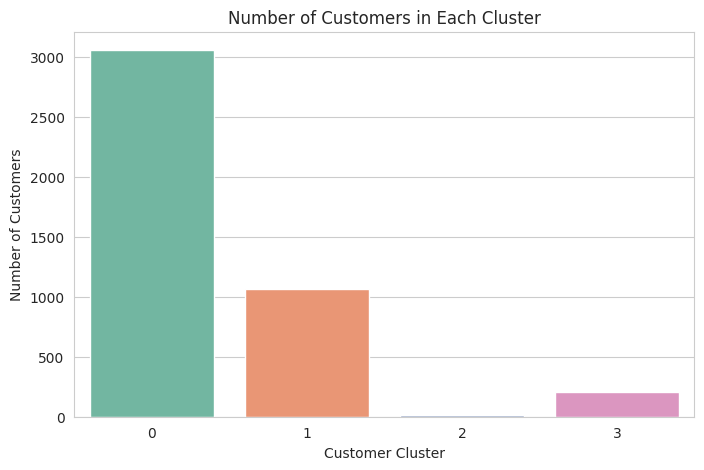

In [32]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=rfm,
    x="Cluster",
    hue="Cluster",
    palette="Set2",
    legend=False
)

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Customer Cluster")
plt.ylabel("Number of Customers")

plt.show()

## 28. Visualising Customer Clusters

Scatter plots are used to visualise the separation between customer
segments based on their purchasing behaviour.

The first plot compares Frequency and Monetary value, helping identify
customers who purchase frequently and contribute high revenue.

The second plot compares Recency and Monetary value, showing the relationship
between customer activity and spending.

These visualisations provide an intuitive view of how K-Means has grouped
customers with similar purchasing patterns.

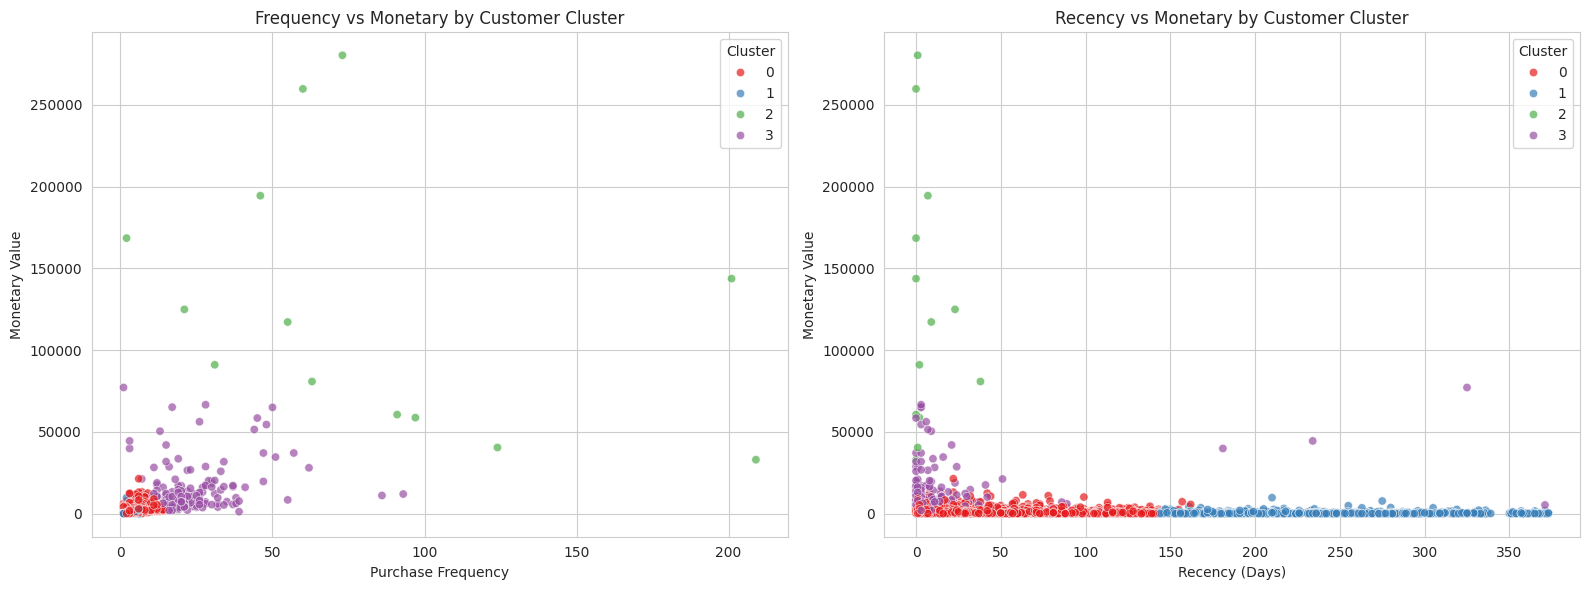

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Frequency vs Monetary
sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="Set1",
    ax=axes[0],
    alpha=0.7
)

axes[0].set_title("Frequency vs Monetary by Customer Cluster")
axes[0].set_xlabel("Purchase Frequency")
axes[0].set_ylabel("Monetary Value")

# Recency vs Monetary
sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="Set1",
    ax=axes[1],
    alpha=0.7
)

axes[1].set_title("Recency vs Monetary by Customer Cluster")
axes[1].set_xlabel("Recency (Days)")
axes[1].set_ylabel("Monetary Value")

plt.tight_layout()
plt.show()

### Observation

The scatter plots show meaningful differences between the customer
segments. High-value customers tend to have higher purchase frequency and
monetary contribution, while inactive customers generally show lower
frequency and spending.

The plots also show that the VIP segment is clearly separated from the
majority of customers because of its exceptionally high purchase frequency
and monetary value.

## 29. Customer Segment Interpretation and Marketing Strategy

Based on the cluster-level RFM profiles, the four customer segments can be
interpreted according to their purchasing behaviour.

### Cluster 0 – Regular Customers

These customers purchase relatively recently and have moderate purchase
frequency and spending. They represent the largest customer group.

**Marketing Action:** Encourage repeat purchases through personalised
product recommendations, loyalty points, and limited-time offers.

### Cluster 1 – At-Risk / Low-Value Customers

These customers have high Recency values, meaning they have not purchased
recently. They also have relatively low Frequency and Monetary values.

**Marketing Action:** Use re-engagement campaigns, personalised discounts,
reminder emails, and win-back offers to encourage another purchase.

### Cluster 2 – VIP Customers

This is a very small but extremely valuable segment. These customers have
very low Recency, exceptionally high Frequency, and extremely high Monetary
value.

**Marketing Action:** Provide VIP treatment such as exclusive products,
early access to new products, premium customer support, and personalised
offers. These customers should receive high-priority retention efforts.

### Cluster 3 – Loyal High-Value Customers

These customers purchase very recently, have high purchase frequency, and
generate substantial revenue.

**Marketing Action:** Strengthen loyalty using membership benefits,
cross-selling, upselling, loyalty rewards, and personalised campaigns.

### Overall Business Insight

The segmentation demonstrates that customers do not contribute equally to
business revenue. A small group of high-value customers generates
substantially more revenue than the typical customer. Therefore, marketing
resources should be allocated differently across segments rather than using
the same strategy for the entire customer base.

In [34]:
cluster_summary = rfm.groupby("Cluster").agg(
    Customer_Count=("CustomerID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")
).round(2)

cluster_summary

,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,3054,42.70,3.68,1353.63
1,1067,247.08,1.55,478.85
2,13,6.38,82.54,127187.96
3,204,14.50,22.33,12690.50


## 30. Final Customer Segment Labels

To make the clustering results easier to understand from a business
perspective, descriptive names are assigned to the four clusters based on
their RFM characteristics.

The labels reflect customer engagement, purchasing frequency, and monetary
contribution.

In [35]:
segment_names = {
    0: "Regular Customers",
    1: "At-Risk / Low-Value Customers",
    2: "VIP Customers",
    3: "Loyal High-Value Customers"
}

rfm["Segment"] = rfm["Cluster"].map(segment_names)

rfm[["CustomerID", "Recency", "Frequency", "Monetary", "Cluster", "Segment"]].head(10)

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,325,1,77183.60,3,Loyal High-Value Customers
1,12347.0,1,7,4310.00,0,Regular Customers
2,12348.0,74,4,1797.24,0,Regular Customers
3,12349.0,18,1,1757.55,0,Regular Customers
4,12350.0,309,1,334.40,1,At-Risk / Low-Value Customers
5,12352.0,35,8,2506.04,0,Regular Customers
6,12353.0,203,1,89.00,1,At-Risk / Low-Value Customers
7,12354.0,231,1,1079.40,1,At-Risk / Low-Value Customers
8,12355.0,213,1,459.40,1,At-Risk / Low-Value Customers
9,12356.0,22,3,2811.43,0,Regular Customers


## 31. Business Insights

The RFM-based K-Means analysis identified four distinct customer segments
with different purchasing behaviours.

### Insight 1: Regular Customers Form the Largest Segment

Cluster 0 contains 3,054 customers, making it the largest segment. These
customers show relatively recent activity, moderate purchase frequency,
and moderate spending. This group represents the core customer base and
provides an opportunity for increasing customer lifetime value.

### Insight 2: A Significant Group of Customers Is At Risk

Cluster 1 contains 1,067 customers with an average Recency of 247.08 days,
Frequency of 1.55 purchases, and Monetary value of 478.85. These customers
have relatively low engagement and may require reactivation campaigns.

### Insight 3: A Very Small VIP Group Generates Exceptional Value

Cluster 2 contains only 13 customers, but their average Frequency is 82.54
and average Monetary value is 127,187.96. This demonstrates that a very
small number of customers can contribute disproportionately high value.

### Insight 4: Loyal High-Value Customers Are an Important Segment

Cluster 3 contains 204 customers with an average Recency of only 14.50 days,
Frequency of 22.33, and Monetary value of 12,690.50. These customers are
highly engaged and represent an important group for retention and
cross-selling.

## Actionable Business Recommendations

### Recommendation 1 – Retain VIP Customers

The business should provide VIP customers with exclusive benefits,
personalised offers, early access to products, and premium customer support.
Because this segment has exceptionally high monetary value, preventing
customer churn should be a priority.

### Recommendation 2 – Run Win-Back Campaigns

The At-Risk / Low-Value segment should receive targeted re-engagement
campaigns. Personalised discounts, product reminders, and limited-time
offers can be used to encourage these customers to make another purchase.

### Recommendation 3 – Increase the Value of Regular Customers

Regular customers can be encouraged to move toward higher-value behaviour
through loyalty programmes, personalised recommendations, cross-selling,
and volume-based incentives.

### Recommendation 4 – Strengthen High-Value Customer Loyalty

Loyal High-Value customers should receive personalised rewards and
exclusive membership benefits. Cross-selling and upselling can further
increase their lifetime value.

## Conclusion

RFM analysis combined with K-Means clustering successfully segmented the
customer base into four distinct behavioural groups. The analysis shows
that customers have substantially different levels of engagement, purchase
frequency, and monetary contribution.

The segmentation enables the business to move from a one-size-fits-all
marketing strategy toward targeted customer relationship management.
Different campaigns can be designed for regular, at-risk, VIP, and loyal
high-value customers, improving customer retention and potentially
increasing overall revenue.

In [36]:
# Save the final customer segmentation dataset
rfm.to_csv("customer_segmentation_RFM_results.csv", index=False)

print("Final RFM segmentation file saved successfully!")
print("Rows:", len(rfm))
print("Columns:", len(rfm.columns))

Final RFM segmentation file saved successfully!
Rows: 4338
Columns: 7


# Project Completion Summary

This project applied RFM (Recency, Frequency, Monetary) analysis and K-Means
clustering to segment 4,338 retail customers based on their purchasing
behaviour.

The analysis involved data cleaning, missing-value treatment, duplicate
removal, cancelled transaction filtering, feature engineering,
standardisation, exploratory analysis, Elbow Method evaluation, and
unsupervised machine learning.

Four customer segments were identified: Regular Customers, At-Risk /
Low-Value Customers, VIP Customers, and Loyal High-Value Customers.

The results demonstrate how data analytics and machine learning can support
targeted marketing, customer retention, loyalty programmes, and revenue
growth. The project strengthened practical skills in Python, Pandas,
Seaborn, Matplotlib, Scikit-learn, RFM analysis, and K-Means clustering.